# Introduction: Semantic Representation and Hierarchical Clustering

This notebook shifts our analytical focus from spatial brain activation to the semantic relationships between our curated cognitive terms. We aim to investigate whether our predefined, data-driven categories (Affect, Valuation, and Social) naturally emerge from the high-dimensional semantic space of a Pre-trained Language Model (PLM).


In [1]:
from sentence_transformers import SentenceTransformer
import pandas as pd
from pathlib import Path
from scipy.cluster.hierarchy import fcluster
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import  linkage
import json
from sklearn.metrics import adjusted_rand_score
import utils


plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'Arial'

DATA_PATH = Path('../data')
RESULTS_PATH = Path('../results')
PLOTS_PATH = Path('../plots')
DOCUMENTS_PATH = Path('../documents')
PLOT_KWARGS_DICT = dict(dpi=300, transparent=True, bbox_inches='tight')

/home/guoqiu/.conda/envs/vmpfc_general/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Contextualized Embedding Generation

We utilize **Qwen3-Embedding-8B**, a robust large language model, to extract vector representations for each psychological term. The weights for the `Qwen3-Embedding-8B` model are open-source and can be officially downloaded from the [Hugging Face](https://huggingface.co/Qwen/Qwen3-Embedding-8B). Once downloaded, the entire model directory must be placed in the `../data/Qwen3-Embedding-8B` folder.

Crucially, to prevent the model from capturing the everyday, colloquial usage of these words, we embed each term within a domain-specific prompt template: *"cognitive neuroscience concept of {term}."* This context forces the model to generate scientific, domain-aligned embeddings.

In [2]:
# load models
qwen_model = SentenceTransformer(str(DATA_PATH / 'Qwen3-Embedding-8B'), device='cuda:1')

# get term and term mapping
with open(DATA_PATH / 'neurosynth_data/term_mapping.json', 'r', encoding='utf8') as f:
    term_mapping_dict = json.load(f)
    term_list = list(term_mapping_dict.keys())

# get embeddings from contextualized terms
template_str = "cognitive neuroscience concept of {term}."
embedding_array = qwen_model.encode([template_str.format(term=x) for x in term_list])
embedding_df = pd.DataFrame(embedding_array, index=term_list)

# set up color mapping for latter plot
category_color_mapping_dict = {'affect': '#c00000',  'valuation': '#eab200','social': '#0036d9', }

Loading weights: 100%|██████████| 398/398 [00:28<00:00, 13.91it/s]


In [3]:
term_mapping_dict_50 = {k: v for (k, v) in term_mapping_dict.items() if v != "others"}
term_list_50 = list(term_mapping_dict_50.keys())
embedding_array_50 = embedding_df.loc[term_list_50, :].copy().values

term_list_15 = term_list_50[:15]
term_mapping_dict_15 = {k: v for k, v in term_mapping_dict.items() if k in term_list_15}
embedding_array_15 = embedding_df.loc[term_list_15, :].copy().values

# Hierarchical Clustering & Visualization
Once the terms are mapped into a semantic vector space, we perform agglomerative hierarchical clustering using **Cosine distance** to evaluate their similarities. This is executed at two scales:
* **Core Set (Top 15 Terms):** Using the `complete` linkage method to assess the distinct boundaries between our most highly associated terms.
* **Extended Set (Top 50 Terms):** Using the `average` linkage method to map the broader and more complex semantic landscape.

Finally, the hierarchical relationships are visualized as circular dendrograms. Each term is color-coded according to its original theoretical category (`Affect`, `Valuation`, or `Social`), allowing for intuitive visual inspection of the alignment between the model's semantic space and our predefined psychological domains.

## Term 15

Adjusted Rand Index: 1.000


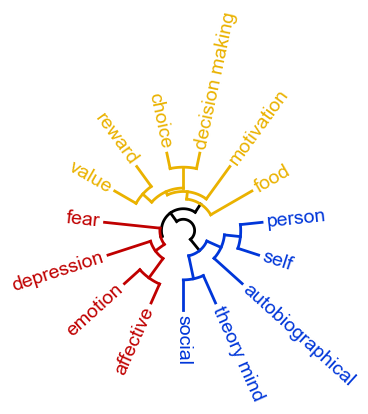

In [4]:
Z_15 = linkage(embedding_array_15, method='complete', metric='cosine')

predict_label_list = fcluster(Z_15, t=3, criterion='maxclust')
true_label_list = list(term_mapping_dict_15.values())
ari_value = adjusted_rand_score(true_label_list, predict_label_list)
print(f"Adjusted Rand Index: {ari_value:.3f}")



term_color_mapping_dict_15 = {k: category_color_mapping_dict[v] for (k, v) in term_mapping_dict_15.items()}
fig, ax = utils.plot.circular_dendrogram(
    Z_15, term_color_mapping_dict_15,
    figsize=(4, 4), line_width=2, font_size=14, gap_fraction=1/len(term_color_mapping_dict_15), r_inner=0.1, rotation_degrees=-180, flip=True
)


fig.savefig(PLOTS_PATH / 'PLM_terms_15.png', **PLOT_KWARGS_DICT)
fig.savefig(PLOTS_PATH / 'PLM_terms_15.svg', **PLOT_KWARGS_DICT)


## Terms 50

Adjusted Rand Index: 0.838


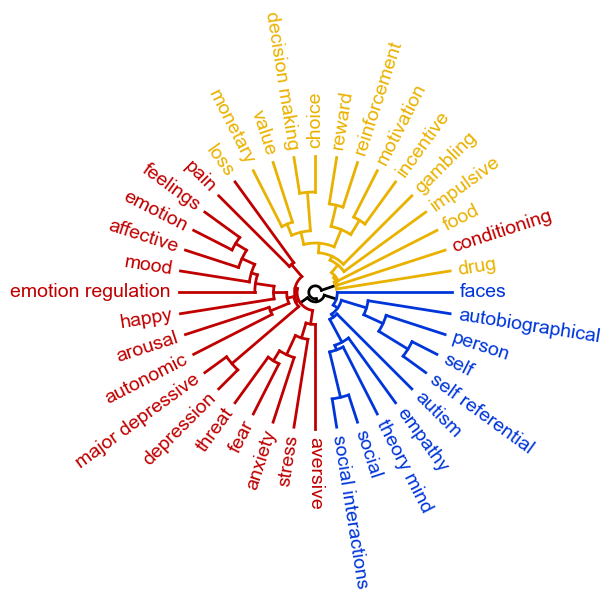

In [5]:
Z_50 = linkage(embedding_array_50, method='average', metric='cosine')

predict_label_list = fcluster(Z_50, t=3, criterion='maxclust')
true_label_list = list(term_mapping_dict_50.values())
ari_value = adjusted_rand_score(true_label_list, predict_label_list)
print(f"Adjusted Rand Index: {ari_value:.3f}")

term_color_mapping_dict_50 = {k: category_color_mapping_dict[v] for (k, v) in term_mapping_dict_50.items()}
Z_50 = utils.plot.circular_dendrogram_make_adjacent(Z_50, list(term_color_mapping_dict_50.keys()), 'loss', 'monetary')
fig, ax = utils.plot.circular_dendrogram(
    Z_50, term_color_mapping_dict_50,
    figsize=(6, 6), line_width=2, font_size=14, gap_fraction=1/len(term_color_mapping_dict_50), r_inner=0., r_outer=1, rotation_degrees=-90
)

fig.savefig(PLOTS_PATH / 'PLM_terms_50.png', **PLOT_KWARGS_DICT)
fig.savefig(PLOTS_PATH / 'PLM_terms_50.svg', **PLOT_KWARGS_DICT)